# Efficient Frontier and Portfolio Optimization

In this notebook, we generate thousands of random portfolio allocations using the same assets from the Monte Carlo analysis.  

For each portfolio, we calculate expected annual return, annualized volatility, and Sharpe Ratio.  

The objective is to identify:

- the portfolio with the highest Sharpe Ratio
- the portfolio with the lowest volatility
- the risk-return trade-off across different portfolio allocations

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

# If the notebook is running from the "notebooks" folder, go one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns generated in the first notebook
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [12]:
# Basic inputs
trading_days = 252
risk_free_rate = 0.00

assets = returns.columns
n_assets = len(assets)

mean_daily_returns = returns.mean()
cov_daily_matrix = returns.cov()

print("Assets:")
print(list(assets))
print(f"Number of assets: {n_assets}")

Assets:
['GLD', 'QQQ', 'SPY', 'TLT']
Number of assets: 4


In [13]:
# Generate random portfolios
n_portfolios = 20_000

np.random.seed(42)

portfolio_results = []

for _ in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights = weights / weights.sum()

    annualized_return = np.dot(weights, mean_daily_returns) * trading_days

    annualized_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_daily_matrix * trading_days, weights))
    )

    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    result = {
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio
    }

    for asset, weight in zip(assets, weights):
        result[f"Weight {asset}"] = weight

    portfolio_results.append(result)

efficient_frontier_df = pd.DataFrame(portfolio_results)

efficient_frontier_df.head()

,Annualized Return,Annualized Volatility,Sharpe Ratio,Weight GLD,Weight QQQ,Weight SPY,Weight TLT
0,0.137348,0.143175,0.959300,0.141022,0.357962,0.275610,0.225406
1,0.047765,0.118627,0.402647,0.126201,0.126181,0.046983,0.700635
2,0.101684,0.114417,0.888718,0.261391,0.307900,0.008951,0.421758
3,0.136261,0.126294,1.078923,0.590380,0.150594,0.128953,0.130073
4,0.141730,0.141610,1.000847,0.196011,0.338079,0.278284,0.187627


In [14]:
# Identify optimal portfolios
max_sharpe_portfolio = efficient_frontier_df.loc[
    efficient_frontier_df["Sharpe Ratio"].idxmax()
]

min_volatility_portfolio = efficient_frontier_df.loc[
    efficient_frontier_df["Annualized Volatility"].idxmin()
]

optimal_portfolios = pd.DataFrame({
    "Maximum Sharpe Portfolio": max_sharpe_portfolio,
    "Minimum Volatility Portfolio": min_volatility_portfolio
}).T

optimal_portfolios

,Annualized Return,Annualized Volatility,Sharpe Ratio,Weight GLD,Weight QQQ,Weight SPY,Weight TLT
Maximum Sharpe Portfolio,0.170932,0.147231,1.160975,0.576134,0.409758,0.006256,0.007852
Minimum Volatility Portfolio,0.080923,0.103427,0.782422,0.260210,0.000466,0.298086,0.441238


In [15]:
# Save results
efficient_frontier_df.to_csv(
    OUTPUTS_DIR / "efficient_frontier_portfolios.csv",
    index=False
)

optimal_portfolios.to_csv(
    OUTPUTS_DIR / "optimal_portfolios.csv"
)

print("Efficient frontier results saved successfully.")

Efficient frontier results saved successfully.


## Efficient Frontier Visualization

The chart below shows the risk-return profile of 20,000 randomly generated portfolios.  
Each point represents a different portfolio allocation.  

The Maximum Sharpe Portfolio represents the portfolio with the best risk-adjusted return, while the Minimum Volatility Portfolio represents the lowest-risk allocation among the simulated portfolios.

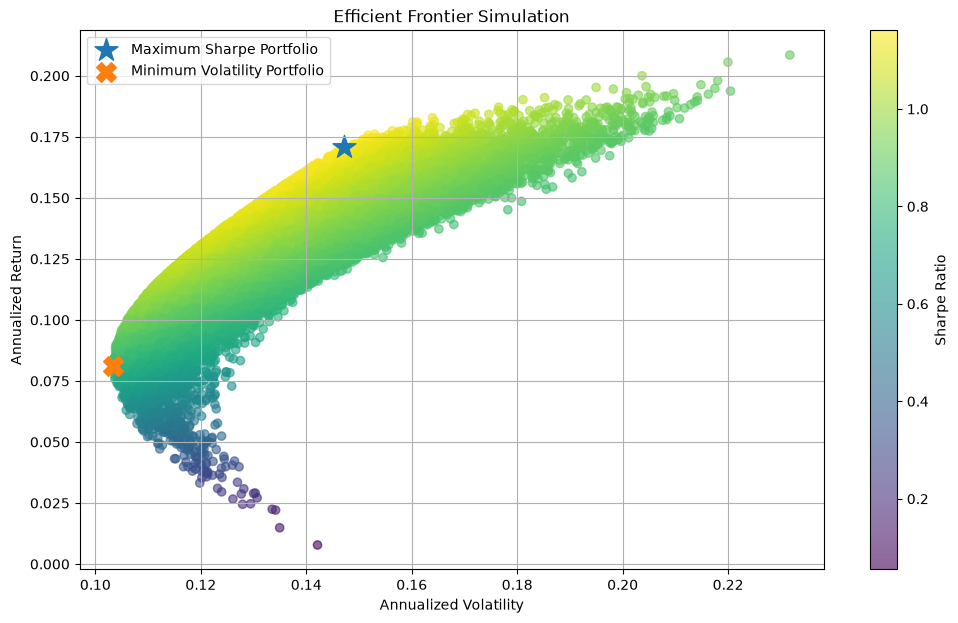

In [16]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    efficient_frontier_df["Annualized Volatility"],
    efficient_frontier_df["Annualized Return"],
    c=efficient_frontier_df["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

# Highlight Maximum Sharpe Portfolio
plt.scatter(
    max_sharpe_portfolio["Annualized Volatility"],
    max_sharpe_portfolio["Annualized Return"],
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

# Highlight Minimum Volatility Portfolio
plt.scatter(
    min_volatility_portfolio["Annualized Volatility"],
    min_volatility_portfolio["Annualized Return"],
    marker="X",
    s=200,
    label="Minimum Volatility Portfolio"
)

plt.title("Efficient Frontier Simulation")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.grid(True)

plt.savefig(IMAGES_DIR / "efficient_frontier.png", dpi=300, bbox_inches="tight")

plt.show()

## Optimal Portfolio Allocations

The following chart compares the asset weights of the Maximum Sharpe Portfolio and the Minimum Volatility Portfolio.

In [17]:
# Extract only portfolio weights
weight_columns = [col for col in optimal_portfolios.columns if col.startswith("Weight")]

optimal_weights = optimal_portfolios[weight_columns]

# Clean column names
optimal_weights.columns = [
    col.replace("Weight ", "") for col in optimal_weights.columns
]

optimal_weights

,GLD,QQQ,SPY,TLT
Maximum Sharpe Portfolio,0.576134,0.409758,0.006256,0.007852
Minimum Volatility Portfolio,0.260210,0.000466,0.298086,0.441238


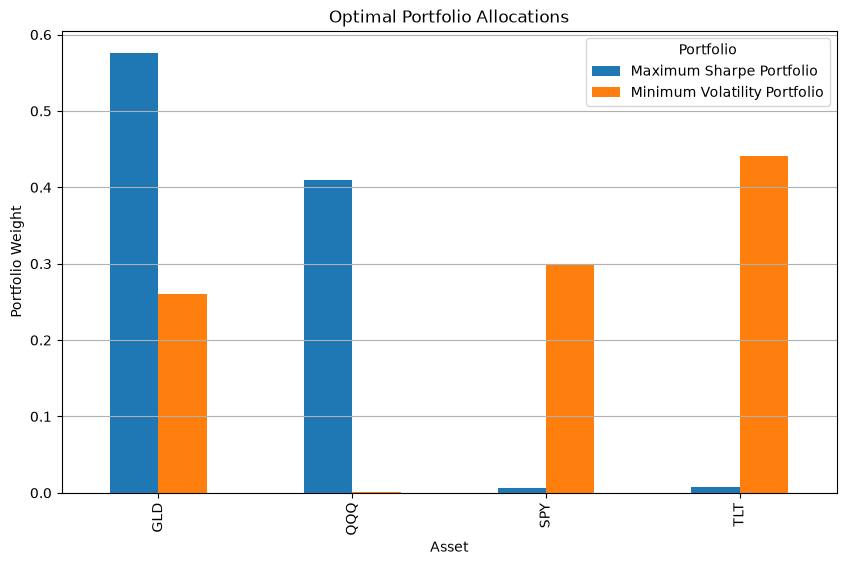

In [18]:
ax = optimal_weights.T.plot(kind="bar", figsize=(10, 6))

plt.title("Optimal Portfolio Allocations")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "optimal_portfolio_allocations.png", dpi=300, bbox_inches="tight")

plt.show()

## Interpretation

The Efficient Frontier simulation shows the trade-off between expected return and portfolio risk across thousands of randomly generated allocations.

The Maximum Sharpe Portfolio represents the allocation with the best risk-adjusted return. It does not necessarily have the highest expected return, but it offers the best balance between return and volatility among the simulated portfolios.

The Minimum Volatility Portfolio represents the lowest-risk allocation. It typically has a lower expected return, but it may be more suitable for investors who prioritize capital preservation and lower portfolio fluctuations.

Overall, the Efficient Frontier helps identify more efficient portfolio allocations compared to manually selected weights.